In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import glob

import viser
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


# Part 0: Dataset

## Camera Calibration

In [5]:
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, aruco_params)

all_object_points = []
all_image_points = []
calibration_tag_size = 0.06

object_points_single = np.array([
    [0, 0, 0],
    [calibration_tag_size, 0, 0],
    [calibration_tag_size, calibration_tag_size, 0],
    [0, calibration_tag_size, 0]
], dtype=np.float32)

for img_path in glob.glob('../images/calibration_images/*.JPG'):
    img = cv2.imread(img_path)
    img_size = (img.shape[1], img.shape[0])
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)
    
    if ids is not None:
        print(f"Found {len(ids)} markers in {img_path}")
        for i in range(len(ids)):
            all_object_points.append(object_points_single)
            all_image_points.append(corners[i].reshape(4, 2))

ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    all_object_points,  
    all_image_points,   
    img_size,           
    None,              
    None               
)

print(f"\nCamera Matrix (K):")
print(camera_matrix)
print(f"\nDistortion Coefficients:")
print(dist_coeffs)

Found 6 markers in ../images/calibration_images/IMG_9281 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9300 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9298 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9302 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9283 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9287 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9306 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9304 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9278 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9285 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9303 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9282 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9280 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9299 2.JPG
Found 6 markers in ../images/calibration_images/IMG_9301 2.JPG
Found 6 markers in ../images/calibration_images/IMG_930

## Estimating Camera Pose

In [6]:
nerf_tag_size = 0.1

object_points = np.array([
    [0, 0, 0],
    [nerf_tag_size, 0, 0],
    [nerf_tag_size, nerf_tag_size, 0],
    [0, nerf_tag_size, 0]
], dtype=np.float32)

c2w_matrices = []
valid_images = []

for img_path in glob.glob('../images/nerf_images/*.JPG'):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)

    if len(corners) > 0:
        image_points = corners[0].reshape(4, 2)

        success, rvec, tvec = cv2.solvePnP(
            object_points,
            image_points,
            camera_matrix,
            dist_coeffs
        )

        if success:
            print(f"Successfully estimated pose for {img_path}")
            valid_images.append(img)
            R, _ = cv2.Rodrigues(rvec)
            w2c = np.eye(4)
            w2c[:3, :3] = R
            w2c[:3, 3] = tvec.flatten()
            c2w = np.linalg.inv(w2c)
            c2w_matrices.append(c2w)
        else:
            print(f"Failed to estimate pose for {img_path}")
    else:
        print(f"No markers found in {img_path}")

c2w_matrices = np.array(c2w_matrices)

    

Successfully estimated pose for ../images/nerf_images/IMG_9319 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9361 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9345 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9347 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9326 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9363 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9367 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9343 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9341 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9339 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9358 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9365 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9346 2.JPG
Successfully estimated pose for ../images/nerf_images/IMG_9362 2.JPG
Successfully estimated pose for ..

In [ ]:

   
server = viser.ViserServer(share=True)
H, W = valid_images[0].shape[:2]

for i, (img, c2w) in enumerate(zip(valid_images, c2w_matrices)):
    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, camera_matrix[0, 0]),
        aspect=W / H,
        scale=0.02,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=img
    )
   
while True:
    time.sleep(0.1)

╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://high-res-bias.share.viser.studio

(viser) Connection opened (0, 1 total), 190 persistent messages

(viser) Connection closed (0, 0 total)

KeyboardInterrupt: 

(viser) Disconnected from share URL

(viser) Disconnected from share URL

## Undistorting and Dataset Creation

In [ ]:
undistorted_images = []
h, w = valid_images[0].shape[:2]

new_camera_matrix, roi = cv2.getOptimalNewCameraMatrix(
    camera_matrix, dist_coeffs, (w, h), alpha=0, newImgSize=(w, h)
)

for img in valid_images:
    # Undistort with new camera matrix
    undistorted_img = cv2.undistort(img, camera_matrix, dist_coeffs, None, new_camera_matrix)
    
    # Crop to valid ROI to remove black boundaries
    x, y, w_roi, h_roi = roi
    if w_roi > 0 and h_roi > 0:
        undistorted_img = undistorted_img[y:y+h_roi, x:x+w_roi]
    
    undistorted_images.append(undistorted_img)

n = len(undistorted_images)
indices = np.arange(n)
np.random.seed(10)
np.random.shuffle(indices)

n_train = int(0.8 * n)
n_val = int(0.1 * n)

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train+n_val]
test_indices = indices[n_train+n_val:]

images_train = np.array([undistorted_images[i] for i in train_indices])
images_val = np.array([undistorted_images[i] for i in val_indices])
images_test = np.array([undistorted_images[i] for i in test_indices])

c2ws_train = np.array([c2w_matrices[i] for i in train_indices])
c2ws_val = np.array([c2w_matrices[i] for i in val_indices])
c2ws_test = np.array([c2w_matrices[i] for i in test_indices])

output_path = '../data/nerf_dataset'
focal = new_camera_matrix[0, 0]

np.savez(
    output_path,
    images_train=images_train,
    c2ws_train=c2ws_train,
    images_val=images_val,
    c2ws_val=c2ws_val,
    c2ws_test=c2ws_test,
    focal=focal
)

print(f"\nDataset saved to {output_path}")
print(f"Focal length: {focal}")
print(f"Number of training images: {len(images_train)}")
print(f"Number of validation images: {len(images_val)}")
print(f"Number of test images: {len(images_test)}")

Original camera matrix:
[[3.20187447e+03 0.00000000e+00 1.47125652e+03]
 [0.00000000e+00 3.06439323e+03 1.90759674e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

New camera matrix:
[[3.69029561e+03 0.00000000e+00 1.35926909e+03]
 [0.00000000e+00 3.54602121e+03 1.88048685e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Valid ROI: x=0, y=0, w=3023, h=4031

Original image size: (4032, 3024, 3)
Cropped image size: (4031, 3023, 3)

Dataset saved to ../data/nerf_dataset
Focal length: 3690.295614819235
Number of training images: 36
Number of validation images: 4
Number of test images: 6


# Part 1: 2D Neural Field

In [27]:
class PositionalEncoding:
    " applies sinusoidal encoding to the input "

    def __init__(self, L):
        self.L = L
        self.funcs = [torch.sin, torch.cos]

    def __call__(self, x):
        encoded = [x]

        for l in range(self.L):
            freq = 2**l
            for func in self.funcs:
                encoded.append(func(freq * np.pi * x))

        return torch.cat(encoded, dim=-1)

    def get_output_dim(self, input_dim):
        return input_dim * (2 * self.L + 1)

class MLP(nn.Module):
    " maps 2D coordinates to RGB colors "
    def __init__(self, L=10, hidden_dim=256):
        super().__init__()

        self.pe = PositionalEncoding(L)
        input_dim = self.pe.get_output_dim(2)

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), 
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.pe(x)
        colors = self.network(encoded)
        return colors

class ImageDataset(Dataset):
    " all (coordinate, color) pairs in an image "

    def __init__(self, image_path):
        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img)
        self.H, self.W, _ = img_array.shape

        self.colors = (img_array.reshape(-1, 3) / 255.0).astype(np.float32)

        y_coords, x_coords = np.meshgrid(
            np.arange(self.H),
            np.arange(self.W),
            indexing='ij'
        )

        self.coords = np.stack([
            x_coords.flatten() / self.W,
            y_coords.flatten() / self.H
        ], axis=-1).astype(np.float32)

        self.img_array = img_array

    def __len__(self):
        return len(self.coords)
    
    def __getitem__(self, idx):
        return self.coords[idx], self.colors[idx]

    def get_full_image(self):
        return self.img_array / 255.0

def compute_psnr(mse):
    return 10 * np.log10(1 / mse)

def render_full_image(model, dataset, device):
    model.eval()
    H, W = dataset.H, dataset.W

    all_coords = torch.from_numpy(dataset.coords).to(device)

    batch_size = 10000
    all_colors = []

    with torch.no_grad():
        for i in range(0, len(all_coords), batch_size):
            batch_coords = all_coords[i:i+batch_size]
            batch_colors = model(batch_coords)
            all_colors.append(batch_colors.cpu().numpy())

    all_colors = np.concatenate(all_colors, axis=0)
    rendered = all_colors.reshape(H, W, 3)

    model.train()
    return rendered

def train_model(model, dataloader, device, num_epochs=2500, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    losses, psnrs = [], []

    snapshot_iters = [100, 500, 1000, 2000]
    snapshots = {}

    model.train()
    iteration = 0
    pbar = tqdm(total=num_epochs, desc="Training")

    while iteration < num_epochs:
        for coords, colors in dataloader:
            if iteration >= num_epochs:
                break

            coords = coords.float().to(device)
            colors = colors.float().to(device)

            pred_colors = model(coords)
            loss = criterion(pred_colors, colors)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            psnr = compute_psnr(loss.item())

            losses.append(loss.item())
            psnrs.append(psnr)

            if iteration % 10 == 0:
                pbar.set_postfix({'Loss': f'{loss.item():.6f}', 'PSNR': f'{psnr:.2f} dB'})
            pbar.update(1)

            if iteration in snapshot_iters:
                print(f"Saving snapshot at iteration {iteration}")
                snapshots[iteration] = render_full_image(model, dataset, device)

            iteration += 1

    pbar.close()

    return losses, psnrs, snapshots

# model = MLP(L=15).to(device)
# dataset = ImageDataset('../images/nerf_images/IMG_9315 3.JPG')
# batch_size = 10000
# dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# losses, psnrs, snapshots = train_model(model, dataloader, device)

# # Show training progression with original image
# fig, axes = plt.subplots(1, 5, figsize=(25, 5))  # 1 row, 5 columns

# # First subplot: Original image
# axes[0].imshow(dataset.get_full_image())
# axes[0].set_title("Original Image", fontsize=14)
# axes[0].axis('off')

# # Remaining subplots: Training progression
# sorted_snaps = sorted(snapshots.items())
# for idx, (iter_num, snapshot) in enumerate(sorted_snaps):
#     axes[idx + 1].imshow(snapshot)
#     axes[idx + 1].set_title(f"Iteration {iter_num}", fontsize=14)
#     axes[idx + 1].axis('off')

# plt.suptitle("Training Progression", fontsize=16)
# plt.tight_layout()
# plt.savefig('../images/deliverables/part_1_training_progression_my_image.png', dpi=150, bbox_inches='tight')
# plt.show()

# # Plot PSNR curve
# plt.figure(figsize=(10, 5))
# plt.plot(psnrs)
# plt.xlabel('Iteration')
# plt.ylabel('PSNR (dB)')
# plt.title('Training PSNR over Time')
# plt.grid(True)
# plt.show()

# print(f"\nFinal PSNR: {psnrs[-1]:.2f} dB")




In [26]:
experiments = [
    {'L': 2, 'hidden_dim': 64, 'name': 'Low Freq (L=2), Narrow (64)'},
    {'L': 10, 'hidden_dim': 64, 'name': 'High Freq (L=10), Narrow (64)'},
    {'L': 2, 'hidden_dim': 256, 'name': 'Low Freq (L=2), Wide (256)'},
    {'L': 10, 'hidden_dim': 256, 'name': 'High Freq (L=10), Wide (256)'},
]

dataset = ImageDataset('../images/part_1_image.jpg')
dataloader = DataLoader(dataset, batch_size=10000, shuffle=True)

results = {}

for exp in experiments:
    print(f"\n{'='*60}")
    print(f"Training: {exp['name']}")
    print(f"{'='*60}")
    
    model = MLP(L=exp['L'], hidden_dim=exp['hidden_dim']).to(device)
    
    losses, psnrs, snapshots = train_model(
        model, dataloader, device, 
        num_epochs=1500, 
        lr=1e-2
    )
    
    final_render = render_full_image(model, dataset, device)
    results[exp['name']] = {
        'image': final_render,
        'final_psnr': psnrs[-1]
    }

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    axes[idx].imshow(result['image'])
    axes[idx].set_title(f"{name}\nPSNR: {result['final_psnr']:.2f} dB", fontsize=12)
    axes[idx].axis('off')

plt.suptitle("Hyperparameter Comparison (Final Results)", fontsize=16)
plt.tight_layout()
plt.savefig('../images/deliverables/part_1_hyperparameter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


Training: Low Freq (L=2), Narrow (64)


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Part 1: Model Architecture Report

**Network Structure:**
- **Input:** 2D pixel coordinates (x, y) normalized to [0, 1]
- **Positional Encoding:** L=10 frequency levels
  - Maps 2D input → 42D encoded vector
- **Hidden Layers:** 3 layers × 256 units with ReLU activation
- **Output Layer:** 3 units (RGB) with Sigmoid activation

**Training Configuration:**
- Optimizer: Adam
- Learning Rate: 1e-2
- Batch Size: 10,000 pixels per iteration
- Training Iterations: 2000-2500
- Loss Function: MSE (Mean Squared Error)
- Metric: PSNR (Peak Signal-to-Noise Ratio)
- Device: MPS (Apple Silicon GPU)

# Part 2: Neural Radiance Fields

In [9]:
def transform(c2w, x_c):
    "transforms points from camera space to world space"
    ones = np.ones_like(x_c[..., :1])
    x_c_homogeneous = np.concatenate([x_c, ones], axis=-1)

    x_w_homogenous = x_c_homogeneous @ c2w.T
    x_w = x_w_homogenous[..., :3] / x_w_homogenous[..., 3:4]
    return x_w

x = np.array([[1.0, 0.0, 3.0]])

c2w = np.array([
    [1, 0, 0, 5],
    [0, 1, 0, 2],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
], dtype=np.float32)


print(x == transform(np.linalg.inv(c2w), transform(c2w, x)))

def pixel_to_camera(K, uv, s):
    "convert pixel coordinates to camera coordinates"

    fx = K[0, 0]
    fy = K[1, 1]
    cx = K[0, 2]
    cy = K[1, 2]

    u = uv[..., 0]
    v = uv[..., 1]

    x_c = (u - cx) / fx * s
    y_c = (v - cy) / fy * s
    z_c = np.full_like(x_c, s)

    x_c = np.stack([x_c, y_c, z_c], axis=-1)
    return x_c

def pixel_to_ray(K, c2w, uv):
    "convert pixel coordinates to rays in world space"

    ray_origins = c2w[:3, 3]

    x_c = pixel_to_camera(K, uv, 1.0)
    x_w = transform(c2w, x_c)

    ray_directions = x_w - ray_origins
    ray_directions = ray_directions / np.linalg.norm(ray_directions, axis=-1, keepdims=True)

    ray_origins = np.broadcast_to(ray_origins, ray_directions.shape)

    return ray_origins, ray_directions

def sample_rays_from_images(images, c2ws, K, N):
    "sample N random rays from multiple images"

    M, H, W, C = images.shape

    y, x = np.meshgrid(
        np.arange(H),
        np.arange(W),
        indexing='ij'
    )

    pixels = np.stack([x, y], axis=-1).astype(np.float32) + 0.5

    pixels_flat = np.tile(pixels.reshape(-1, 2), (M, 1))
    colors_flat = images.reshape(-1, 3)
    img_indices = np.repeat(np.arange(M), H * W)

    total_pixels = M * H * W
    sampled_idx = np.random.choice(total_pixels, size=N, replace=False)

    sampled_pixels = pixels_flat[sampled_idx]
    sampled_colors = colors_flat[sampled_idx]
    sampled_img_indices = img_indices[sampled_idx]

    rays_o = np.zeros((N, 3), dtype=np.float32)
    rays_d = np.zeros((N, 3), dtype=np.float32)

    for img_idx in np.unique(sampled_img_indices):
        img_mask = sampled_img_indices == img_idx
        pixels_for_img = sampled_pixels[img_mask]
        rays_o_for_img, rays_d_for_img = pixel_to_ray(K, c2ws[img_idx], pixels_for_img)
        
        # Write rays back to their original positions
        rays_o[img_mask] = rays_o_for_img
        rays_d[img_mask] = rays_d_for_img

    return rays_o, rays_d, sampled_colors
    
def sample_points_along_rays(rays_o, rays_d, near=2.0, far=6.0, n_samples=64, perturb=True):
    N = rays_o.shape[0]

    t_vals = np.linspace(near, far, n_samples, dtype=np.float32) 
    t_vals = np.broadcast_to(t_vals, (N, n_samples))

    if perturb:
        bin_width = (far - near) / n_samples

        t_vals = t_vals + np.random.uniform(0, bin_width, size=(N, n_samples))

    points = rays_o[:, None, :] + t_vals[..., None] * rays_d[:, None, :]

    return points, t_vals
        

[[ True  True  True]]


In [28]:
class RaysDataset(Dataset):

    def __init__(self, images, c2ws, K):
        self.images = images
        self.c2ws = c2ws
        self.K = K

        M, H, W, C = images.shape
        self.M, self.H, self.W = M, H, W

        y, x = np.meshgrid(
            np.arange(H),
            np.arange(W),
            indexing='ij'
        )

        self.uvs = np.stack([x, y], axis=-1).astype(np.float32).reshape(-1, 2)

        self.rays_o, self.rays_d, self.pixels = sample_rays_from_images(
            images, c2ws, K, N=M * H * W
        )

    def __len__(self):
        return len(self.rays_o)
    
    def __getitem__(self, idx):
        return (
            self.rays_o[idx],
            self.rays_d[idx],
            self.pixels[idx]
        )

## 2.4: NeRF Network

In [29]:
class NeRFNetwork(nn.Module):
    def __init__(self, pos_L=10, dir_L=4, hidden_dim=256):
        super().__init__()

        self.pos_encoder = PositionalEncoding(pos_L)
        self.dir_encoder = PositionalEncoding(dir_L)

        pos_dim = self.pos_encoder.get_output_dim(3)
        dir_dim = self.dir_encoder.get_output_dim(3)

        # process position (density)

        self.layers1 = nn.Sequential(
            nn.Linear(pos_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )

        # process with skip connection

        self.layers2 = nn.Sequential(
            nn.Linear(hidden_dim + pos_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )

        # Density head

        self.density_head = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.ReLU()
        )

        # Feature layer before color prediction

        self.feature_layer = nn.Linear(hidden_dim, hidden_dim)

        # Color head

        self.color_head = nn.Sequential(
            nn.Linear(hidden_dim + dir_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3),
            nn.Sigmoid()
        )

    def forward(self, positions, directions):
        pos_encoded = self.pos_encoder(positions)
        dir_encoded = self.dir_encoder(directions)

        # First pass
        x = self.layers1(pos_encoded)

        # Skip connection
        x = torch.cat([x, pos_encoded], dim=-1)
        x = self.layers2(x)

        # Predict Density
        density = self.density_head(x)
        
        # Extract features for color prediction
        features = self.feature_layer(x)

        # Predict color
        color_input = torch.cat([features, dir_encoded], dim=-1)
        colors = self.color_head(color_input)

        return density, colors    

## 2.5: Volume Rendering

In [30]:
def volrend(sigmas, rgbs, step_size):
    # opacity at each sample
    alphas = 1.0 - torch.exp(-sigmas * step_size)

    # Transmittance
    transmittance = torch.cumprod(1 - alphas, dim=1)
    transmittance = torch.cat([
        torch.ones_like(transmittance[:, :1, :]),
        transmittance[:, :-1, :]
    ], dim=1)

    weights = transmittance * alphas
    rendered_colors = torch.sum(weights * rgbs, dim=1)
    return rendered_colors

## Training NeRF Network on Lego Dataset

In [6]:
lego_data = np.load('../data/lego_200x200.npz')

lego_images_train = lego_data['images_train'] / 255.0
lego_c2ws_train = lego_data['c2ws_train']

lego_images_val = lego_data['images_val'] / 255.0
lego_c2ws_val = lego_data['c2ws_val']

lego_c2ws_test = lego_data['c2ws_test']

lego_focal = lego_data['focal']

In [7]:
images_train = lego_images_train
c2ws_train = lego_c2ws_train
images_val = lego_images_val
c2ws_val = lego_c2ws_val
focal = float(lego_focal)

H, W = lego_images_train.shape[1:3]
K = np.array([
    [focal, 0, W / 2],
    [0, focal, H / 2],
    [0, 0, 1]
], dtype=np.float32)

# Create dataset
train_dataset = RaysDataset(images_train, c2ws_train, K)
train_loader = DataLoader(train_dataset, batch_size = 10000, shuffle=True, num_workers=0)

near, far, n_samples = 2.0, 6.0, 64
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model = NeRFNetwork(pos_L=10, dir_L=4, hidden_dim=256).to(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()

def render_image(model, c2w, K, H, W, near, far, n_samples, device, chunk_size=1024):
    model.eval()
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    pixels = np.stack([x, y], axis=-1).astype(np.float32) + 0.5
    rays_o, rays_d = pixel_to_ray(K, c2w, pixels.reshape(-1, 2))

    all_colors = []
    with torch.no_grad():
        for i in range(0, len(rays_o), chunk_size):
            rays_o_chunk = rays_o[i:i+chunk_size]
            rays_d_chunk = rays_d[i:i+chunk_size]

            points, t_vals = sample_points_along_rays(
                rays_o_chunk, rays_d_chunk, near, far, n_samples, perturb=False
            )

            points_torch = torch.from_numpy(points).float().to(device)
            rays_d_torch = torch.from_numpy(rays_d_chunk).float().to(device)
            rays_d_expanded = rays_d_torch[:, None, :].expand_as(points_torch)

            density, colors = model(points_torch, rays_d_expanded)
            step_size = (far - near) / n_samples
            rendered_chunk = volrend(density, colors, step_size)
            all_colors.append(rendered_chunk.cpu().numpy())

    model.train()
    return np.concatenate(all_colors, axis=0).reshape(H, W, 3)

num_iterations = 1000
val_every = 100
save_snapshots_at = [100, 300, 500, 1000]

train_losses = []
val_psnrs = []
val_iterations = []
snapshots = {}

pbar = tqdm(total=num_iterations, desc="Training NeRF")
iteration = 0

while iteration < num_iterations:
    for rays_o, rays_d, gt_colors in train_loader:
        if iteration >= num_iterations:
            break
        
        rays_o = rays_o.float().to(device)
        rays_d = rays_d.float().to(device)
        gt_colors = gt_colors.float().to(device)

        points, _ = sample_points_along_rays(
            rays_o.cpu().numpy(), rays_d.cpu().numpy(), near, far, n_samples, perturb=True
        )
        points = torch.from_numpy(points).float().to(device)
        rays_d_expanded = rays_d[:, None, :].expand_as(points)

        density, colors = model(points, rays_d_expanded)
        step_size = (far - near) / n_samples
        rendered_colors = volrend(density, colors, step_size)

        loss = criterion(rendered_colors, gt_colors)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if iteration % 10 == 0:
            pbar.set_postfix({'Loss': f'{loss.item():.6f}', 'PSNR': f'{compute_psnr(loss.item()):.2f} dB'})

        if (iteration + 1) % val_every == 0 or iteration == 0:
            pbar.write(f"\n[Iter {iteration+1}] Validating...")
            val_psnr_sum = 0
            for val_idx in range(len(images_val)):
                rendered_val = render_image(model, c2ws_val[val_idx], K, H, W, near, far, n_samples, device)
                mse = np.mean((rendered_val - images_val[val_idx])**2)
                val_psnr_sum += compute_psnr(mse)
            avg_val_psnr = val_psnr_sum / len(images_val)
            val_psnrs.append(avg_val_psnr)
            val_iterations.append(iteration + 1)
            pbar.write(f"[Iter {iteration+1}] Val PSNR: {avg_val_psnr:.2f} dB")
        
        if (iteration + 1) in save_snapshots_at:
            pbar.write(f"[Iter {iteration+1}] Saving snapshot...")
            snapshots[iteration + 1] = render_image(model, c2ws_val[0], K, H, W, near, far, n_samples, device)
        
        pbar.update(1)
        iteration += 1

pbar.close()
print(f'final PSNR: {val_psnrs[-1]:.2f} dB')

NameError: name 'RaysDataset' is not defined

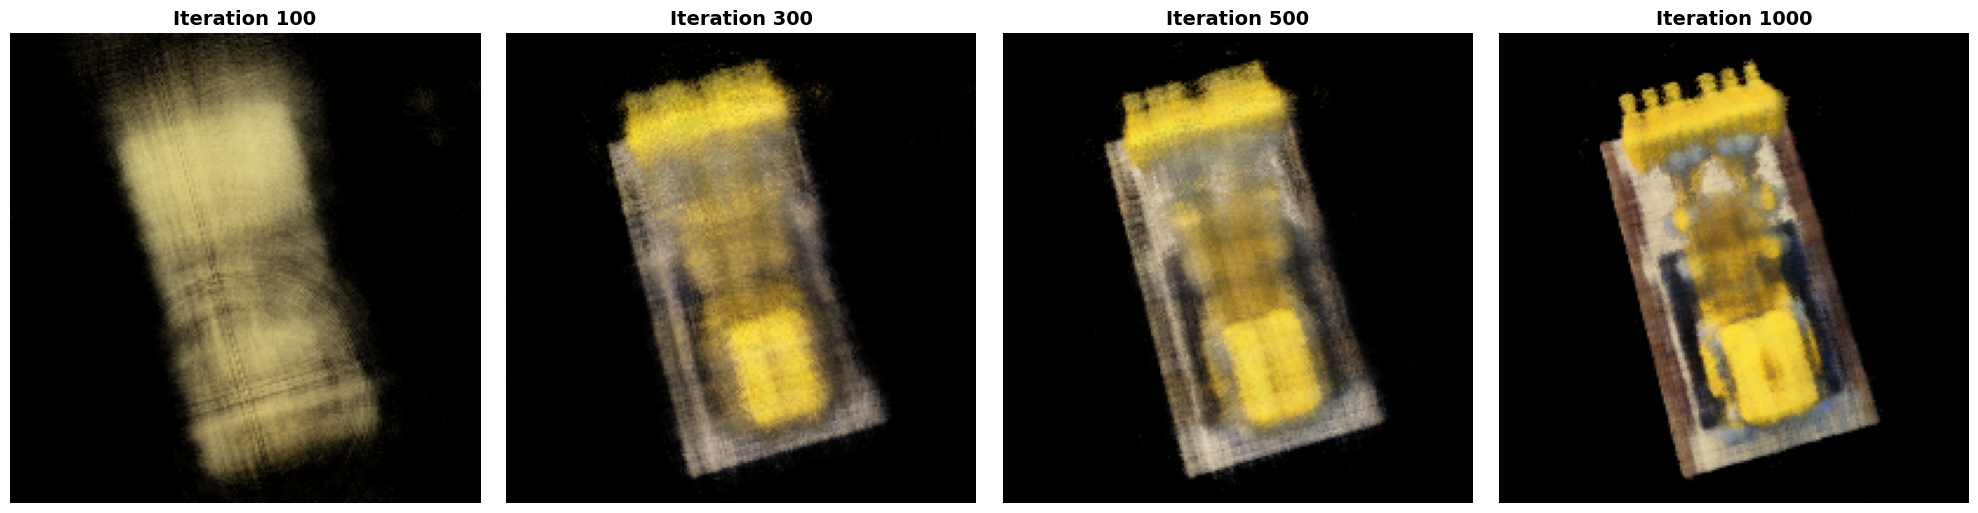

Saved training progression with 4 snapshots


In [31]:
fig, axes = plt.subplots(1, len(snapshots), figsize=(5*len(snapshots), 5))

for idx, (iteration, rendered_img) in enumerate(sorted(snapshots.items())):
    axes[idx].imshow(np.clip(rendered_img, 0, 1))
    axes[idx].set_title(f'Iteration {iteration}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('../images/deliverables/lego_training_progression.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved training progression with {len(snapshots)} snapshots")

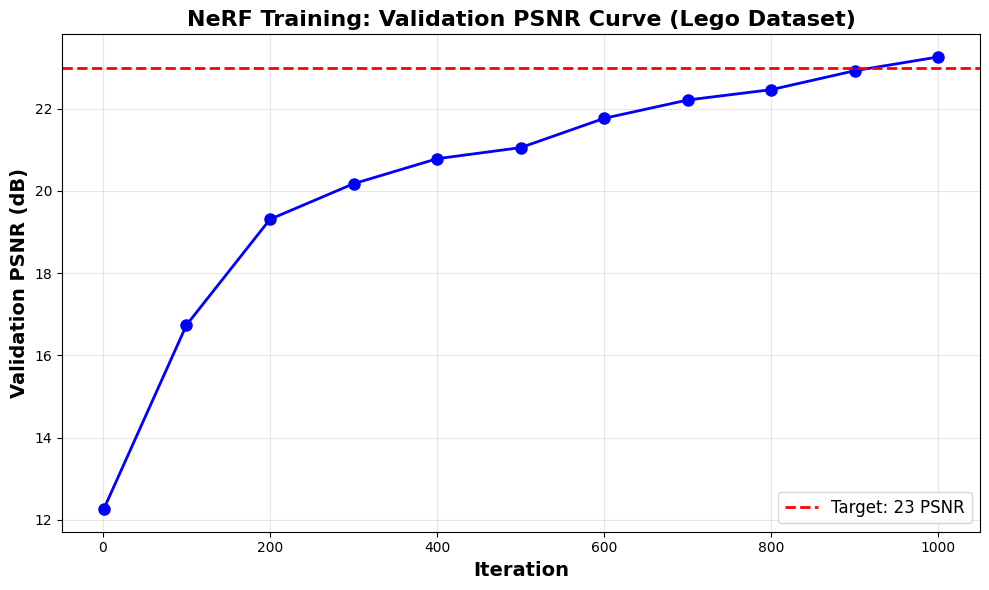

Final Val PSNR: 23.26 dB (✅ PASSED)


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(val_iterations, val_psnrs, 'o-', linewidth=2, markersize=8, color='blue')
plt.axhline(y=23, color='r', linestyle='--', linewidth=2, label='Target: 23 PSNR')
plt.xlabel('Iteration', fontsize=14, fontweight='bold')
plt.ylabel('Validation PSNR (dB)', fontsize=14, fontweight='bold')
plt.title('NeRF Training: Validation PSNR Curve (Lego Dataset)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../images/deliverables/lego_psnr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Rendering novel views from test cameras...


Rendering test views:   0%|          | 0/60 [00:00<?, ?it/s]

/var/folders/nc/dkzh6vs93fq3m59dzmkbrq1h0000gn/T/ipykernel_23413/3034630932.py:6: RuntimeWarning: divide by zero encountered in matmul
  x_w_homogenous = x_c_homogeneous @ c2w.T
/var/folders/nc/dkzh6vs93fq3m59dzmkbrq1h0000gn/T/ipykernel_23413/3034630932.py:6: RuntimeWarning: overflow encountered in matmul
  x_w_homogenous = x_c_homogeneous @ c2w.T
/var/folders/nc/dkzh6vs93fq3m59dzmkbrq1h0000gn/T/ipykernel_23413/3034630932.py:6: RuntimeWarning: invalid value encountered in matmul
  x_w_homogenous = x_c_homogeneous @ c2w.T


✅ Saved novel view GIF: 60 frames at 30 fps


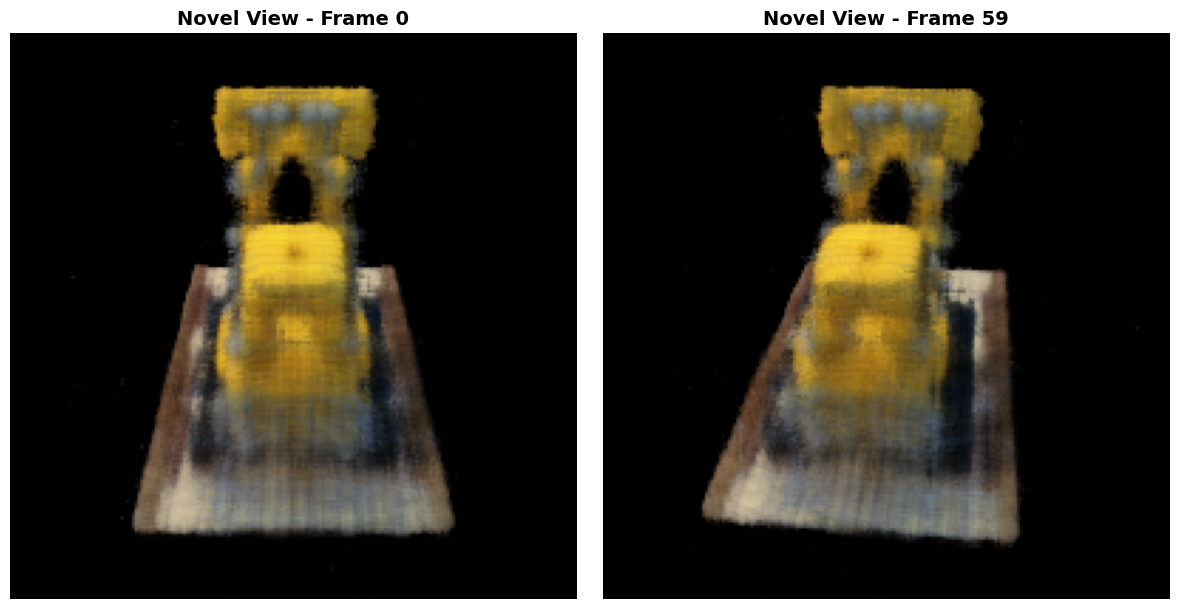

In [ ]:
from PIL import Image
import imageio

novel_frames = []

for i, c2w_test in enumerate(tqdm(lego_c2ws_test, desc="Rendering test views")):
    rendered = render_image(model, c2w_test, K, H, W, near, far, n_samples, device)
    rendered_uint8 = (np.clip(rendered, 0, 1) * 255).astype(np.uint8)
    novel_frames.append(rendered_uint8)

imageio.mimsave('../images/deliverables/lego_novel_views.gif', novel_frames, fps=30, loop=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(novel_frames[0])
axes[0].set_title('Novel View - Frame 0', fontsize=14, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(novel_frames[-1])
axes[1].set_title(f'Novel View - Frame {len(novel_frames)-1}', fontsize=14, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
indices = np.random.choice(H*W, size=100, replace=False)

y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
pixels = np.stack([x, y], axis=-1).astype(np.float32) + 0.5
pixels_flat = pixels.reshape(-1, 2)
sampled_pixels = pixels_flat[indices]

rays_o, rays_d = pixel_to_ray(K, c2ws_train[0], sampled_pixels)
points, _ = sample_points_along_rays(rays_o, rays_d, near=2.0, far=6.0, n_samples=64, perturb=True)

server = viser.ViserServer(share=True)

for i, (image, c2w) in enumerate(zip(images_train, c2ws_train)):
    server.scene.add_camera_frustum(
        f"/cameras/{i}",
        fov=2 * np.arctan2(H / 2, K[0, 0]),
        aspect=W / H,
        scale=0.15,
        wxyz=viser.transforms.SO3.from_matrix(c2w[:3, :3]).wxyz,
        position=c2w[:3, 3],
        image=image
    )

for i, (o, d) in enumerate(zip(rays_o, rays_d)):
    server.scene.add_spline_catmull_rom(
        f"/rays/{i}",
        positions=np.stack((o, o + d * 6.0)),
        color=(255, 0, 0)
    )

server.scene.add_point_cloud(
    f"/samples",
    colors=(np.ones_like(points).reshape(-1, 3) * 255).astype(np.uint8),
    points=points.reshape(-1, 3),
    point_size=0.02
)

try:
    while True:
        time.sleep(0.1)
except KeyboardInterrupt:
    print("✅ Visualization stopped")

╭────── viser (listening *:8080) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

(viser) Share URL requested!

(viser) Generated share URL (expires in 24 hours, max 16 clients): https://cold-contrast.share.viser.studio

(viser) Connection opened (0, 1 total), 608 persistent messages

## 2.6: Ran on Colab A100

In [ ]:
!pip install -q tqdm imageio

import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
import warnings
import zipfile

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class PositionalEncoding:
    def __init__(self, L):
        self.L = L
        self.funcs = [torch.sin, torch.cos]

    def __call__(self, x):
        encoded = [x]
        for l in range(self.L):
            freq = 2**l
            for func in self.funcs:
                encoded.append(func(freq * np.pi * x))
        return torch.cat(encoded, dim=-1)

    def get_output_dim(self, input_dim):
        return input_dim * (2 * self.L + 1)

class NeRFNetwork(nn.Module):
    def __init__(self, pos_L=10, dir_L=4, hidden_dim=256):
        super().__init__()
        self.pos_encoder = PositionalEncoding(pos_L)
        self.dir_encoder = PositionalEncoding(dir_L)

        pos_dim = self.pos_encoder.get_output_dim(3)
        dir_dim = self.dir_encoder.get_output_dim(3)

        self.layers1 = nn.Sequential(
            nn.Linear(pos_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )

        self.layers2 = nn.Sequential(
            nn.Linear(hidden_dim + pos_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )

        self.density_head = nn.Sequential(nn.Linear(hidden_dim, 1), nn.ReLU())
        self.feature_layer = nn.Linear(hidden_dim, hidden_dim)
        self.color_head = nn.Sequential(
            nn.Linear(hidden_dim + dir_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3), nn.Sigmoid()
        )

    def forward(self, positions, directions):
        pos_encoded = self.pos_encoder(positions)
        dir_encoded = self.dir_encoder(directions)

        x = self.layers1(pos_encoded)
        x = torch.cat([x, pos_encoded], dim=-1)
        x = self.layers2(x)

        density = self.density_head(x)
        features = self.feature_layer(x)
        color_input = torch.cat([features, dir_encoded], dim=-1)
        colors = self.color_head(color_input)

        return density, colors

def transform(c2w, x_c):
    ones = np.ones_like(x_c[..., :1])
    x_c_homogeneous = np.concatenate([x_c, ones], axis=-1)
    x_w_homogenous = x_c_homogeneous @ c2w.T
    x_w = x_w_homogenous[..., :3] / x_w_homogenous[..., 3:4]
    return x_w

def pixel_to_camera(K, uv, s):
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
    u, v = uv[..., 0], uv[..., 1]
    x_c = (u - cx) / fx * s
    y_c = (v - cy) / fy * s
    z_c = np.full_like(x_c, s)
    return np.stack([x_c, y_c, z_c], axis=-1)

def pixel_to_ray(K, c2w, uv):
    ray_origins = c2w[:3, 3]
    x_c = pixel_to_camera(K, uv, 1.0)
    x_w = transform(c2w, x_c)
    ray_directions = x_w - ray_origins
    ray_directions = ray_directions / np.linalg.norm(ray_directions, axis=-1, keepdims=True)
    ray_origins = np.broadcast_to(ray_origins, ray_directions.shape)
    return ray_origins, ray_directions

def sample_rays_from_images(images, c2ws, K, N):
    M, H, W, C = images.shape
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    pixels = np.stack([x, y], axis=-1).astype(np.float32) + 0.5
    pixels_flat = np.tile(pixels.reshape(-1, 2), (M, 1))
    colors_flat = images.reshape(-1, 3)
    img_indices = np.repeat(np.arange(M), H * W)
    total_pixels = M * H * W
    sampled_idx = np.random.choice(total_pixels, size=N, replace=False)
    sampled_pixels = pixels_flat[sampled_idx]
    sampled_colors = colors_flat[sampled_idx]
    sampled_img_indices = img_indices[sampled_idx]

    rays_o = np.zeros((N, 3), dtype=np.float32)
    rays_d = np.zeros((N, 3), dtype=np.float32)

    for img_idx in np.unique(sampled_img_indices):
        img_mask = sampled_img_indices == img_idx
        pixels_for_img = sampled_pixels[img_mask]
        rays_o_for_img, rays_d_for_img = pixel_to_ray(K, c2ws[img_idx], pixels_for_img)
        rays_o[img_mask] = rays_o_for_img
        rays_d[img_mask] = rays_d_for_img

    return rays_o, rays_d, sampled_colors

def sample_points_along_rays(rays_o, rays_d, near=2, far=6, n_samples=64, perturb=True):
    N = rays_o.shape[0]
    t_vals = np.linspace(near, far, n_samples, dtype=np.float32)
    t_vals = np.broadcast_to(t_vals, (N, n_samples))
    if perturb:
        bin_width = (far - near) / n_samples
        t_vals = t_vals + np.random.uniform(0, bin_width, size=(N, n_samples))
    points = rays_o[:, None, :] + t_vals[..., None] * rays_d[:, None, :]
    return points, t_vals

def volrend(sigmas, rgbs, step_size):
    alphas = 1.0 - torch.exp(-sigmas * step_size)
    transmittance = torch.cumprod(1.0 - alphas, dim=1)
    transmittance = torch.cat([torch.ones_like(transmittance[:, :1, :]), transmittance[:, :-1, :]], dim=1)
    weights = transmittance * alphas
    rendered_colors = torch.sum(weights * rgbs, dim=1)
    return rendered_colors

def compute_psnr(mse):
    return 10 * np.log10(1 / mse)

class RaysDataset(Dataset):
    def __init__(self, images, c2ws, K):
        self.images = images
        self.c2ws = c2ws
        self.K = K
        M, H, W, C = images.shape
        self.M, self.H, self.W = M, H, W

        y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
        self.uvs = np.stack([x, y], axis=-1).astype(np.int32).reshape(-1, 2)

        print(f"   Pre-generating {M * H * W:,} rays...")
        self.rays_o, self.rays_d, self.pixels = sample_rays_from_images(images, c2ws, K, N=M*H*W)
        print(f"   Dataset ready: {len(self.rays_o):,} rays")

    def __len__(self):
        return len(self.rays_o)

    def __getitem__(self, idx):
        return (self.rays_o[idx], self.rays_d[idx], self.pixels[idx])

dataset_path = "/content/lafufu_dataset.npz"


zf = zipfile.ZipFile(dataset_path, "r")

loaded_data = {}

for name in zf.namelist():
    if name.endswith(".npy"):
        loaded_data[name[:-4]] = np.load(zf.open(name))

my_images_train = loaded_data['images_train']
my_images_val = loaded_data['images_val']
c2ws_train = loaded_data['c2ws_train']
c2ws_val = loaded_data['c2ws_val']
K_loaded = loaded_data['K'] 
focal = float(K_loaded[0, 0]) 

scale = 0.4

my_c2ws_train = c2ws_train
my_c2ws_val = c2ws_val
my_focal = focal * scale
my_H, my_W = my_images_train.shape[1:3]
my_K = np.array([[my_focal, 0, my_W/2], [0, my_focal, my_H/2], [0, 0, 1]], dtype=np.float32)


my_train_dataset = RaysDataset(my_images_train, my_c2ws_train, my_K)
my_train_loader = DataLoader(my_train_dataset, batch_size=10000, shuffle=True, num_workers=0)

my_near = 0.35
my_far = 0.75
my_n_samples = 64

my_model = NeRFNetwork(pos_L=10, dir_L=4, hidden_dim=256).to(device)
my_optimizer = optim.Adam(my_model.parameters(), lr=5e-4)
my_criterion = nn.MSELoss()

def my_render_image(model, c2w, K, H, W, near, far, n_samples, device, chunk_size=2048):
    model.eval()
    y, x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    pixels = np.stack([x, y], axis=-1).astype(np.float32) + 0.5
    rays_o, rays_d = pixel_to_ray(K, c2w, pixels.reshape(-1, 2))

    all_colors = []
    with torch.no_grad():
        for i in range(0, len(rays_o), chunk_size):
            rays_o_chunk, rays_d_chunk = rays_o[i:i+chunk_size], rays_d[i:i+chunk_size]
            points, _ = sample_points_along_rays(rays_o_chunk, rays_d_chunk, near, far, n_samples, perturb=False)

            points_torch = torch.from_numpy(points).float().to(device)
            rays_d_torch = torch.from_numpy(rays_d_chunk).float().to(device)
            rays_d_expanded = rays_d_torch[:, None, :].expand_as(points_torch)

            density, colors = model(points_torch, rays_d_expanded)
            step_size = (far - near) / n_samples
            rendered_chunk = volrend(density, colors, step_size)
            all_colors.append(rendered_chunk.cpu().numpy())

    model.train()
    return np.concatenate(all_colors, axis=0).reshape(H, W, 3)

num_iterations = 3000
save_snapshots_at = [500, 1000, 2000, 3000]

my_train_losses = []
my_snapshots = {}

pbar = tqdm(total=num_iterations, desc="Training")
iteration = 0

while iteration < num_iterations:
    for rays_o, rays_d, gt_colors in my_train_loader:
        if iteration >= num_iterations:
            break

        rays_o = rays_o.float().to(device)
        rays_d = rays_d.float().to(device)
        gt_colors = gt_colors.float().to(device)

        points, _ = sample_points_along_rays(rays_o.cpu().numpy(), rays_d.cpu().numpy(), my_near, my_far, my_n_samples, perturb=True)
        points = torch.from_numpy(points).float().to(device)
        rays_d_expanded = rays_d[:, None, :].expand_as(points)

        density, colors = my_model(points, rays_d_expanded)
        step_size = (my_far - my_near) / my_n_samples
        rendered_colors = volrend(density, colors, step_size)

        loss = my_criterion(rendered_colors, gt_colors)
        my_optimizer.zero_grad()
        loss.backward()
        my_optimizer.step()

        my_train_losses.append(loss.item())
        pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'PSNR': f'{compute_psnr(loss.item()):.2f} dB'})
        pbar.update(1)

        if (iteration + 1) in save_snapshots_at:
            my_snapshots[iteration + 1] = my_render_image(my_model, my_c2ws_val[0], my_K, my_H, my_W, my_near, my_far, my_n_samples, device)

        iteration += 1

pbar.close()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (iteration, img) in enumerate(sorted(my_snapshots.items())):
    axes[idx].imshow(np.clip(img, 0, 1))
    axes[idx].set_title(f'Iteration {iteration}', fontsize=14)
    axes[idx].axis('off')
plt.suptitle('Training Progression', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
psnrs = [compute_psnr(loss) for loss in my_train_losses]
plt.plot(psnrs)
plt.xlabel('Iteration')
plt.ylabel('PSNR (dB)')
plt.title('Training PSNR')
plt.grid(True, alpha=0.3)
plt.show()

TRAINING YOUR OWN NERF - OPTIMIZED VERSION

📂 Loading dataset from nerf_dataset.npz...
   Loaded: 36 train, 4 val images
   Original size: 4031×3023
   Focal length: 3690.30

📏 Resizing to 35% with BGR→RGB color correction...
   Resized: (36, 1411, 1058, 3)
   Resolution: 1411×1058, Focal: 1291.60
   Total rays: 53,742,168

📦 Creating RaysDataset...

🔧 Parameters:
   near/far: 0.35m - 0.75m (tighter bounds)
   samples per ray: 64
   batch size: 10,000 rays

🤖 Initializing NeRF model...

🚀 Training for 3000 iterations...
   Estimated time: ~75 minutes



Training:   0%|          | 0/3000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:

import imageio
from matplotlib.gridspec import GridSpec

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for idx, (iteration, img) in enumerate(sorted(my_snapshots.items())):
    axes[idx].imshow(np.clip(img, 0, 1))
    axes[idx].set_title(f'Iteration {iteration}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')
plt.suptitle('Training Progression - My NeRF', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('my_nerf_training_progression.png', dpi=150, bbox_inches='tight')
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss curve
ax1.plot(my_train_losses, linewidth=1.5, color='#e74c3c')
ax1.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax1.set_ylabel('MSE Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(0, len(my_train_losses))

# PSNR curve
psnrs = [compute_psnr(loss) for loss in my_train_losses]
ax2.plot(psnrs, linewidth=1.5, color='#27ae60')
ax2.set_xlabel('Iteration', fontsize=12, fontweight='bold')
ax2.set_ylabel('PSNR (dB)', fontsize=12, fontweight='bold')
ax2.set_title('Training PSNR Over Time', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(0, len(psnrs))

plt.suptitle('My NeRF Training Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('my_nerf_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

# Create circular camera path around the object
def create_circular_poses(center_c2w, n_frames=60, radius_scale=1.0, height_variation=0.0):
    poses = []
    center = center_c2w[:3, 3]  # Camera position
    forward = center_c2w[:3, 2]
    look_at = center - forward * 0.5  # Object is roughly 0.5m in front
    
    for i in range(n_frames):
        theta = 2 * np.pi * i / n_frames
        
        # Circular path
        x = look_at[0] + radius_scale * 0.3 * np.cos(theta)
        y = look_at[1] + radius_scale * 0.3 * np.sin(theta)
        z = look_at[2] + height_variation * np.sin(2 * theta)  # Optional height variation
        
        cam_pos = np.array([x, y, z])
        
        forward = look_at - cam_pos
        forward = forward / np.linalg.norm(forward)
        
        # Up vector (world up)
        up = np.array([0, 0, 1])
        right = np.cross(up, forward)
        right = right / np.linalg.norm(right)
        up = np.cross(forward, right)
        
        c2w = np.eye(4)
        c2w[:3, 0] = right
        c2w[:3, 1] = up
        c2w[:3, 2] = forward
        c2w[:3, 3] = cam_pos
        
        poses.append(c2w)
    
    return poses

n_novel_frames = 60
novel_c2ws = create_circular_poses(my_c2ws_val[0], n_frames=n_novel_frames, radius_scale=1.0)

print(f"   Rendering {n_novel_frames} novel view frames...")
novel_frames = []

for i, c2w_novel in enumerate(tqdm(novel_c2ws, desc="Rendering novel views")):
    rendered = my_render_image(my_model, c2w_novel, my_K, my_H, my_W, my_near, my_far, my_n_samples, device, chunk_size=2048)
    rendered_uint8 = (np.clip(rendered, 0, 1) * 255).astype(np.uint8)
    novel_frames.append(rendered_uint8)

# Display a preview
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
sample_indices = np.linspace(0, len(novel_frames)-1, 8, dtype=int)
for idx, frame_idx in enumerate(sample_indices):
    axes[idx].imshow(novel_frames[frame_idx])
    axes[idx].set_title(f'Frame {frame_idx}', fontsize=10)
    axes[idx].axis('off')
plt.suptitle('Novel View Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()